# Food Access Atlas: tract classification and county summaries

**Analysis notebook — first consolidated version**

This notebook reorganizes Anthony Moore's final DATA 198 Colab pipeline. It classifies the USDA low-income/low-access tract label using demographic and socioeconomic indicators, then summarizes scores by county. It does not forecast future food access or identify causal effects.

The uploaded originals remain unchanged. Map rendering and the collaborative Ollama integration will be connected after the analysis and geographic joins are verified.

**Questions:** How well does the original model distinguish labeled tracts? How does it compare with a simple baseline? How much does performance change without the low-income flag that contributes to the target definition?


## 1. Setup

Extract the project ZIP, install `requirements.txt`, and open this notebook in Jupyter. Run all cells in order. The data are included under `data/raw/`; no Colab upload prompt is needed.

For Colab, upload the project ZIP, extract it, and change the working directory to `food-access-atlas` before running this notebook. The notebook searches the current directory and its parents for the project data.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                            recall_score, f1_score, accuracy_score, brier_score_loss,
                            confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay

SEED = 42
TARGET = 'LILATracts_1And10'
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/raw/food_access_atlas.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Extract the project ZIP and open Jupyter inside food-access-atlas.')
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
DATA_PATH = ROOT / 'data/raw/food_access_atlas.csv'
print('Project:', ROOT.name)
print('Python:', platform.python_version(), '| scikit-learn:', sklearn.__version__)


Project: food-access-atlas
Python: 3.12.14 | scikit-learn: 1.8.0


## 2. Data provenance and validation

The input is the USDA Food Access Research Atlas CSV recovered from the supplied Deepnote export. The accompanying source notes state an initial release in April 2021. The population and occupied-household fields use the 2010 Census; these are historical observations, not current conditions.

`variable_lookup.csv` documents the fields. The target is the low-income/low-access flag at 1 mile in urban areas and 10 miles in rural areas. These distance thresholds are part of the USDA label definition.

Read identifiers as strings and pad tract FIPS to 11 digits **before** deriving county FIPS. Missing feature values are dropped here to preserve the original pipeline; the removal counts are reported.


In [2]:
df = pd.read_csv(DATA_PATH, dtype={'CensusTract': 'string'})
lookup = pd.read_csv(ROOT / 'data/raw/variable_lookup.csv')
original_features = [
    'PovertyRate', 'MedianFamilyIncome', 'Urban', 'TractHUNV', 'TractSNAP',
    'TractBlack', 'TractHispanic', 'TractWhite', 'TractAsian', 'TractKids',
    'TractSeniors', 'Pop2010', 'LowIncomeTracts', 'GroupQuartersFlag'
]
required = original_features + [TARGET, 'CensusTract', 'State', 'County']
missing_columns = sorted(set(required) - set(df.columns))
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')
df['CensusTract'] = df['CensusTract'].str.strip().str.zfill(11)
if not df['CensusTract'].str.fullmatch(r'\d{11}').fillna(False).all():
    raise ValueError('Invalid tract FIPS identifiers.')
if df['CensusTract'].duplicated().any():
    raise ValueError('Duplicate census tract identifiers.')
if not set(df[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError('Target must contain only 0/1 values.')
print(f'Input: {len(df):,} tracts; {df.shape[1]} columns')
print('Missing required values:')
print(df[required].isna().sum().loc[lambda s: s > 0].to_string())
analysis = df.dropna(subset=required).copy()
analysis['county_fips'] = analysis['CensusTract'].str[:5]
print(f'Retained: {len(analysis):,}; removed: {len(df)-len(analysis):,}')
print(f'Observed target prevalence: {analysis[TARGET].mean():.2%}')
print(lookup.loc[lookup['Field'].isin([TARGET, 'LowIncomeTracts']),
                 ['Field', 'Description']].to_string(index=False))


Input: 72,531 tracts; 147 columns
Missing required values:
PovertyRate             3
MedianFamilyIncome    748
TractHUNV               4
TractSNAP               4
TractBlack              4
TractHispanic           4
TractWhite              4
TractAsian              4
TractKids               4
TractSeniors            4
Retained: 71,782; removed: 749
Observed target prevalence: 12.83%
            Field                                                                            Description
LILATracts_1And10 Flag for low-income and low access when considering low accessibilty at 1 and 10 miles
  LowIncomeTracts                                                              Flag for low income tract


## 3. Exploratory summaries

Keep observed USDA prevalence separate from model scores. Neither a county's mean score nor its fraction of labeled tracts measures the fraction of residents affected.


       tracts  observed_prevalence  mean_poverty_rate
Urban                                                
Rural   17223             0.078151          13.218284
Urban   54559             0.144138          15.668093


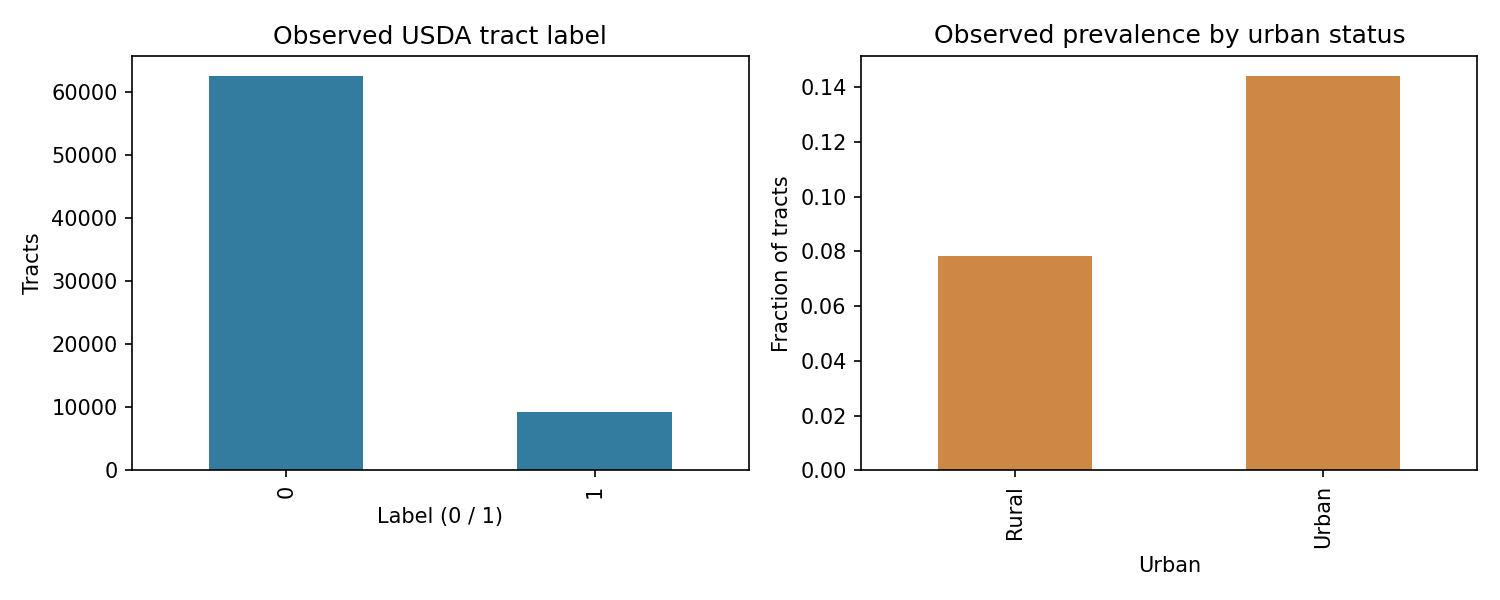

In [3]:
urban_summary = analysis.groupby('Urban').agg(
    tracts=(TARGET, 'size'), observed_prevalence=(TARGET, 'mean'),
    mean_poverty_rate=('PovertyRate', 'mean')
)
print(urban_summary.rename(index={0: 'Rural', 1: 'Urban'}).to_string())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
analysis[TARGET].value_counts().sort_index().plot.bar(ax=axes[0], color='#337ca0')
axes[0].set(title='Observed USDA tract label', xlabel='Label (0 / 1)', ylabel='Tracts')
urban_summary['observed_prevalence'].rename(index={0: 'Rural', 1: 'Urban'}).plot.bar(ax=axes[1], color='#cc8844')
axes[1].set(title='Observed prevalence by urban status', ylabel='Fraction of tracts')
fig.tight_layout()
fig.savefig(RESULTS / 'exploration.png', dpi=150)
plt.show()


## 4. Fixed train/test split

Use an 80/20 stratified split with seed 42, matching the final Colab approach. All models use the same tract indices. Feature selection and scaling use training data only.

This random split evaluates held-out tracts, but nearby tracts may share characteristics. It does not establish performance in unseen counties. A county-held-out evaluation is a next step before claiming geographic generalization.


In [4]:
train_idx, test_idx = train_test_split(
    analysis.index, test_size=0.2, random_state=SEED, stratify=analysis[TARGET]
)
y_train = analysis.loc[train_idx, TARGET].astype(int)
y_test = analysis.loc[test_idx, TARGET].astype(int)
print(f'Training: {len(train_idx):,}; test: {len(test_idx):,}')
print(f'Train prevalence: {y_train.mean():.2%}; test prevalence: {y_test.mean():.2%}')


Training: 57,425; test: 14,357
Train prevalence: 12.83%; test prevalence: 12.83%


## 5. Original model and target-definition sensitivity

The original model ranks 14 predictors using a balanced Random Forest, selects the top 10, and fits standardized, balanced logistic regression.

`LowIncomeTracts` is a component of the low-income/low-access target definition. Its availability may be legitimate for descriptive classification, but it makes performance less informative about independently estimating food-access vulnerability. Compare the original model with a version that excludes that flag. Poverty and income still relate to the label definition, so this is a sensitivity analysis, not a guarantee of fully independent predictors.

The racial/ethnic and age variables are raw counts in the original approach. They can reflect population size as well as composition. Coefficients represent conditional associations, not causes. Future feature engineering should compare appropriate population and household shares.


In [5]:
def fit_selected_logistic(features):
    X_train = analysis.loc[train_idx, features]
    forest = RandomForestClassifier(
        n_estimators=100, random_state=SEED, class_weight='balanced', n_jobs=-1
    )
    forest.fit(X_train, y_train)
    importance = pd.Series(forest.feature_importances_, index=features).sort_values(ascending=False)
    selected = importance.head(10).index.tolist()
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=SEED,
                                          class_weight='balanced'))
    ])
    model.fit(analysis.loc[train_idx, selected], y_train)
    return {'model': model, 'features': selected, 'importance': importance}

models = {
    'original': fit_selected_logistic(original_features),
    'without_low_income_flag': fit_selected_logistic(
        [f for f in original_features if f != 'LowIncomeTracts'])
}
for name, item in models.items():
    print(name, 'selected features:', ', '.join(item['features']))


original selected features: LowIncomeTracts, MedianFamilyIncome, PovertyRate, TractHUNV, TractSNAP, TractAsian, TractHispanic, TractWhite, TractBlack, TractSeniors
without_low_income_flag selected features: MedianFamilyIncome, PovertyRate, TractSNAP, TractHUNV, TractAsian, TractHispanic, TractBlack, TractWhite, TractSeniors, TractKids


## 6. Baseline and held-out evaluation

A constant-prior dummy classifier provides a minimum comparison. Report ROC-AUC and average precision alongside threshold-based precision, recall, F1, and the confusion matrix. The threshold is fixed at 0.5; it is not tuned on the test data.

Balanced class weights alter the fitted probability scale. We therefore call outputs **model scores**, rather than calibrated risk probabilities. Brier score and the calibration plot assess this limitation; they do not calibrate the model.


In [6]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(np.zeros((len(train_idx), 1)), y_train)
probabilities = {'dummy_prior': dummy.predict_proba(np.zeros((len(test_idx), 1)))[:, 1]}
for name, item in models.items():
    probabilities[name] = item['model'].predict_proba(analysis.loc[test_idx, item['features']])[:, 1]
rows = []
for name, scores in probabilities.items():
    pred = (scores >= 0.5).astype(int)
    rows.append(dict(model=name, roc_auc=roc_auc_score(y_test, scores),
        average_precision=average_precision_score(y_test, scores),
        accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred, zero_division=0),
        recall=recall_score(y_test, pred, zero_division=0), f1=f1_score(y_test, pred, zero_division=0),
        brier=brier_score_loss(y_test, scores)))
metrics = pd.DataFrame(rows).set_index('model')
print(metrics.round(4).to_string())
for name, scores in probabilities.items():
    print(name, 'confusion matrix [rows actual 0/1, columns predicted 0/1]:')
    print(confusion_matrix(y_test, scores >= 0.5, labels=[0, 1]))
metrics.to_csv(RESULTS / 'model_metrics.csv')


                         roc_auc  average_precision  accuracy  precision  recall      f1   brier
model                                                                                           
dummy_prior               0.5000             0.1283    0.8717     0.0000  0.0000  0.0000  0.1118
original                  0.8987             0.4527    0.7614     0.3474  0.9788  0.5128  0.1437
without_low_income_flag   0.8249             0.3511    0.7258     0.2946  0.8154  0.4328  0.1785
dummy_prior confusion matrix [rows actual 0/1, columns predicted 0/1]:
[[12515     0]
 [ 1842     0]]
original confusion matrix [rows actual 0/1, columns predicted 0/1]:
[[9128 3387]
 [  39 1803]]
without_low_income_flag confusion matrix [rows actual 0/1, columns predicted 0/1]:
[[8918 3597]
 [ 340 1502]]


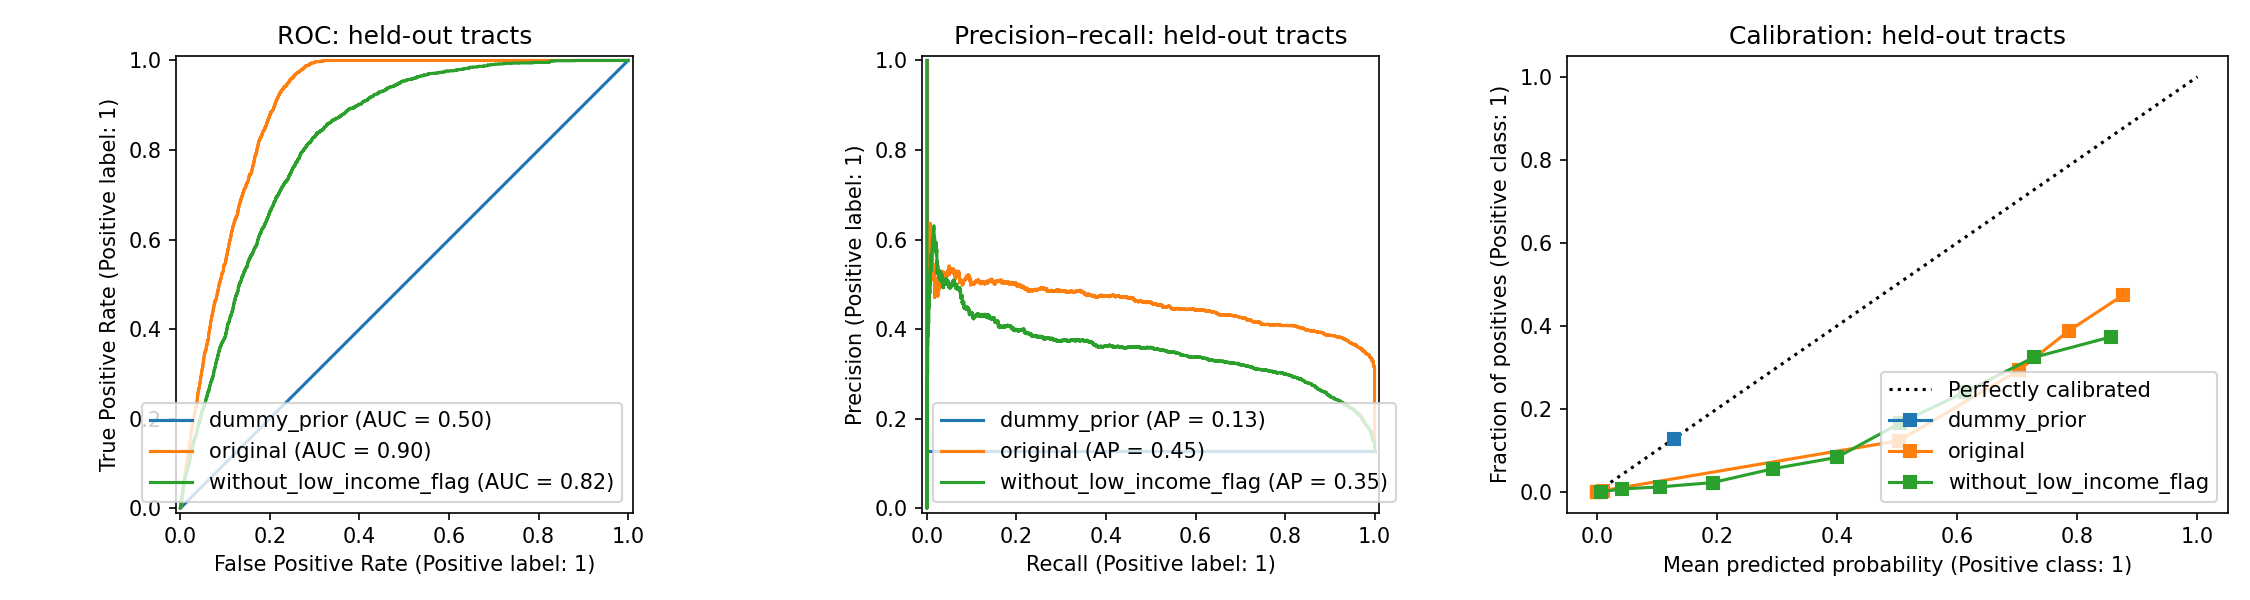

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, scores in probabilities.items():
    RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=name, ax=axes[1])
    CalibrationDisplay.from_predictions(y_test, scores, n_bins=10, strategy='quantile', name=name, ax=axes[2])
axes[0].set_title('ROC: held-out tracts')
axes[1].set_title('Precision–recall: held-out tracts')
axes[2].set_title('Calibration: held-out tracts')
fig.tight_layout()
fig.savefig(RESULTS / 'model_evaluation.png', dpi=150)
plt.show()


## 7. Feature ranking and coefficient interpretation

Random Forest impurity importance is a ranking tool and can favor continuous variables. Standardized logistic coefficients show conditional associations. Neither plot establishes that a feature causes food-access barriers.


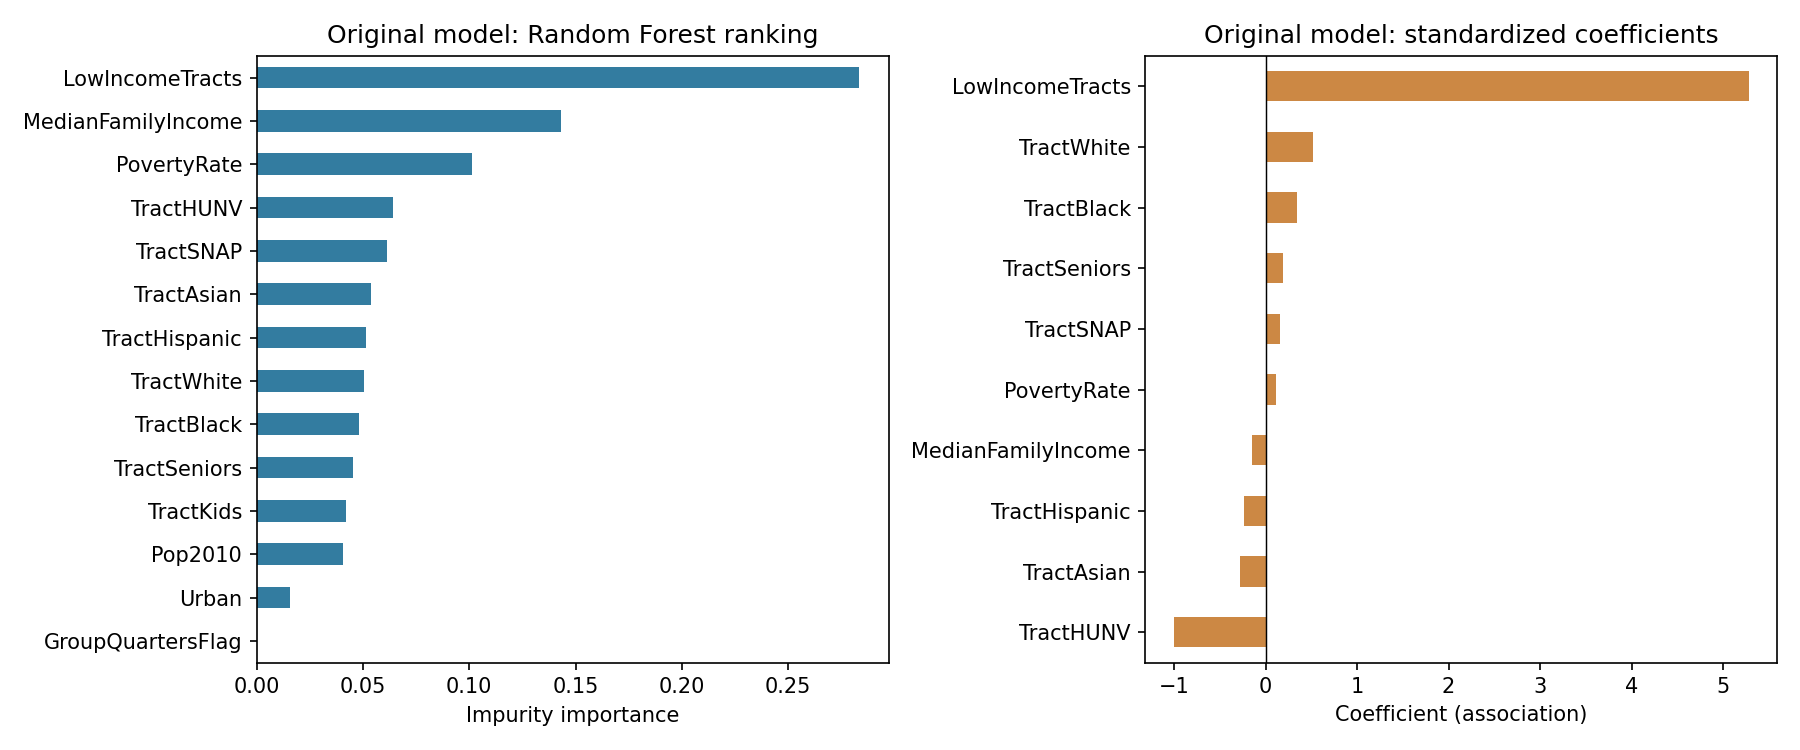

In [8]:
item = models['original']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
item['importance'].sort_values().plot.barh(ax=axes[0], color='#337ca0')
axes[0].set(title='Original model: Random Forest ranking', xlabel='Impurity importance')
coef = pd.Series(item['model'].named_steps['classifier'].coef_[0], index=item['features']).sort_values()
coef.plot.barh(ax=axes[1], color='#cc8844')
axes[1].axvline(0, color='black', linewidth=0.7)
axes[1].set(title='Original model: standardized coefficients', xlabel='Coefficient (association)')
fig.tight_layout()
fig.savefig(RESULTS / 'feature_analysis.png', dpi=150)
plt.show()


## 8. Tract scores and county aggregation

Export both model versions while retaining observed labels. Scores for the full table include training tracts; these maps are descriptive model outputs, not an additional validation set.

Compute county summaries directly from the USDA table before any geometry join. This prevents a mismatched tract boundary file from silently changing the county means. County FIPS values are retained as strings. A future county-boundary join must report unmatched counties and boundary vintages.

`observed_lila_pct` is the percentage of **retained tracts** with the USDA label. `original_mean_model_score` and `without_flag_mean_model_score` are separate unweighted means; they are not combined into a new severity index.


In [9]:
tract_scores = analysis[['CensusTract', 'county_fips', 'State', 'County', TARGET]].copy()
for name, item in models.items():
    tract_scores[name + '_model_score'] = item['model'].predict_proba(analysis[item['features']])[:, 1]
tract_scores['split'] = np.where(tract_scores.index.isin(test_idx), 'test', 'train')
tract_scores.to_csv(RESULTS / 'tract_scores.csv', index=False)
county = tract_scores.groupby('county_fips', as_index=False).agg(
    State=('State', 'first'), County=('County', 'first'),
    retained_tracts=(TARGET, 'size'), observed_lila_fraction=(TARGET, 'mean'),
    original_mean_model_score=('original_model_score', 'mean'),
    without_flag_mean_model_score=('without_low_income_flag_model_score', 'mean')
)
county['observed_lila_pct'] = county.pop('observed_lila_fraction') * 100
original_counts = df.assign(county_fips=df['CensusTract'].str[:5]).groupby('county_fips').size()
county['input_tracts'] = county['county_fips'].map(original_counts)
county['retained_coverage_fraction'] = county['retained_tracts'] / county['input_tracts']
county.to_csv(RESULTS / 'county_scores.csv', index=False)
print(f'Exported {len(tract_scores):,} tract scores and {len(county):,} county summaries.')
print(county.sort_values('original_mean_model_score', ascending=False).head(10).round(3).to_string(index=False))
print('Counties with no retained tracts:', len(original_counts.index.difference(county['county_fips'])))


Exported 71,782 tract scores and 3,139 county summaries.
county_fips          State           County  retained_tracts  original_mean_model_score  without_flag_mean_model_score  observed_lila_pct  input_tracts  retained_coverage_fraction
      37095 North Carolina      Hyde County                1                      0.951                          0.858            100.000             1                         1.0
      05049       Arkansas    Fulton County                2                      0.947                          0.860             50.000             2                         1.0
      51530       Virginia Buena Vista city                1                      0.940                          0.808            100.000             1                         1.0
      29215       Missouri     Texas County                4                      0.940                          0.817             50.000             4                         1.0
      13025        Georgia  Brantley County

## 9. Reproducibility record and next steps

The run metadata records input checksum, package versions, split seed, feature sets, counts, and evaluation values. Use this run's metrics when updating the README; do not copy numbers from an earlier notebook run.

Next: audit target-related predictors more fully, engineer household/population shares, evaluate county-held-out performance, and decide whether calibrated probabilities are needed. Then join county boundaries with an explicit coverage report and integrate the AI feature into reproducible map-building source.

AI recommendations should use supplied county indicators, state their historical scope, and distinguish observed facts from interventions to investigate. The current HTML implementation is not reproduced by this notebook.


In [10]:
run = {
    'input_sha256': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'seed': SEED, 'target': TARGET, 'test_fraction': 0.2,
    'input_tracts': len(df), 'retained_tracts': len(analysis),
    'train_tracts': len(train_idx), 'test_tracts': len(test_idx),
    'versions': {'python': platform.python_version(), 'pandas': pd.__version__,
                 'numpy': np.__version__, 'scikit_learn': sklearn.__version__,
                 'matplotlib': matplotlib.__version__},
    'selected_features': {name: item['features'] for name, item in models.items()},
    'metrics': metrics.reset_index().to_dict(orient='records'),
    'limitations': ['historical data', 'random tract split', 'uncalibrated balanced scores',
                    'raw demographic counts', 'full-table exports include training tracts']
}
(RESULTS / 'run_metadata.json').write_text(json.dumps(run, indent=2))
print('Saved metrics, figures, tract/county scores, and run_metadata.json under results/.')


Saved metrics, figures, tract/county scores, and run_metadata.json under results/.
